In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Pallas Kernel Analysis

In [ ]:
df = pd.read_csv('kernel_experiment_1.csv')

In [ ]:
naives = df.where(df['func_type'] == 'naive').dropna()
fuseds = df.where(df['func_type'] == 'fused').dropna()
ratios = fuseds['time'].values / naives['time'].values
result = naives.copy(deep=True)
result['time'] = ratios
result.rename(columns={'time': 'fused_over_naive_ratio'}, inplace=True)
result.drop('func_type', axis=1, inplace=True)

b_line = result[:8]
d_line = result[8:13]
f_line = result[13:]

In [ ]:
f_line

,B,D,F,B_BLOCK,D_BLOCK,F_BLOCK,fused_over_naive_ratio
27,1024.0,1024.0,256.0,256.0,256.0,256.0,1.058260
29,1024.0,1024.0,512.0,256.0,256.0,256.0,1.183470
31,1024.0,1024.0,1024.0,256.0,256.0,256.0,1.065894
33,1024.0,1024.0,2048.0,256.0,256.0,256.0,1.194185
35,1024.0,1024.0,4096.0,256.0,256.0,256.0,1.205853
37,1024.0,1024.0,8192.0,256.0,256.0,256.0,1.201110


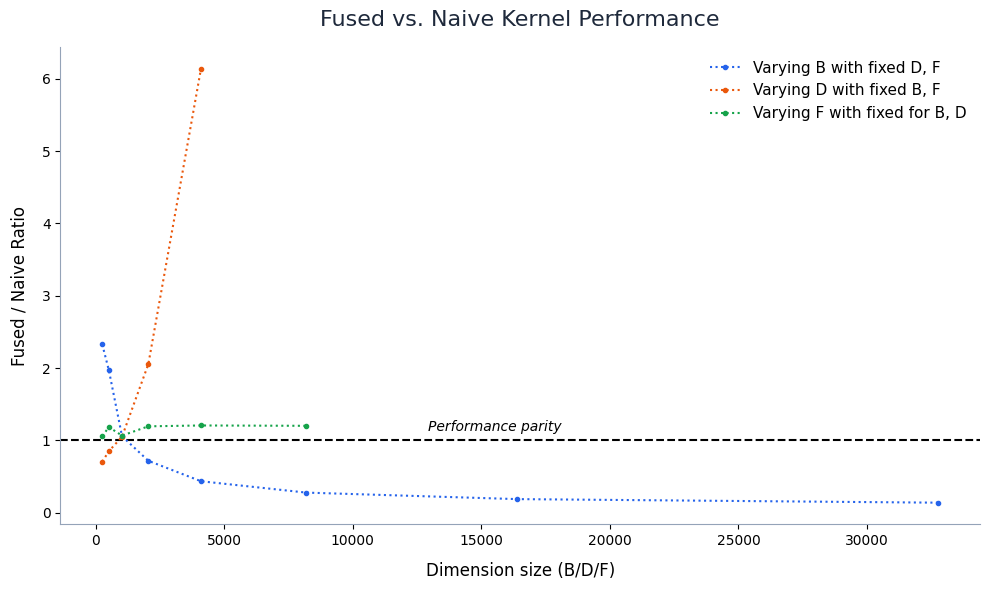

In [ ]:
from matplotlib.lines import lineStyles
# 1. Initialize a clean, modern figure layout
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Set a modern, clean background grid
ax.grid(True, linestyle="--", alpha=0.5, color="#cbd5e1", zorder=0)

# 3. Plot the 3 separate lines with distinct colors and markers
b_line.plot(
    x="B",
    y="fused_over_naive_ratio",
    kind="line",
    ax=ax,
    label="Varying B with fixed D, F",
    color="#2563eb",  # Modern Royal Blue
    linewidth=1.5,
    marker="o",
    markersize=3,
    zorder=3,
    linestyle=":"
)

d_line.plot(
    x="D",
    y="fused_over_naive_ratio",
    kind="line",
    ax=ax,
    label="Varying D with fixed B, F",
    color="#ea580c",  # Modern Deep Orange
    linewidth=1.5,
    linestyle=":",
    marker="o",
    markersize=3,
    zorder=3,
)

f_line.plot(
    x="F",
    y="fused_over_naive_ratio",
    kind="line",
    ax=ax,
    label="Varying F with fixed for B, D",
    color="#16a34a",  # Modern Emerald Green
    marker="o",
    markersize=3,
    linewidth=1.5,
    linestyle=":",
    zorder=3,
)

# ==========================================
# 3. ADD PERFORMANCE PARITY BASELINE
# ==========================================
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.5, zorder=1)

# Dynamically place text just slightly above the baseline to prevent layout collisions
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(
    xmin + (xmax - xmin) * 0.4,
    1.0 + (ymax - ymin) * 0.02,
    "Performance parity",
    color="black",
    fontsize=10,
    style="italic",
    zorder=2,
)

# 4. Apply clean typography and explicit axis descriptions
ax.set_title(
    "Fused vs. Naive Kernel Performance",
    fontsize=16,
    pad=15,
    color="#1e293b",
)
ax.set_xlabel("Dimension size (B/D/F)", fontsize=12, labelpad=10, color="black")
ax.set_ylabel("Fused / Naive Ratio", fontsize=12, labelpad=10, color="black")

# 5. Style the legend and remove unnecessary border boxes
ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=11)

# 6. Remove top and right spine lines for a minimalist look
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# 7. Make the remaining spine lines a softer gray
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#94a3b8")

# 8. Adjust layout spacing and render
plt.tight_layout()
plt.savefig('kernel_plot1.png')

Chinchilla Laws Analysis

In [ ]:
dff = pd.read_csv('moe_results.csv')
df = pd.read_csv('moe_metadata.csv')
df['val_loss'] = dff['val_loss']
df

,num_params,activated_params,num_tokens,flops,val_loss
0,1327565,533453,10000.0,3.200718e+10,2.239483
1,1327565,533453,50000.0,1.600359e+11,1.837974
2,1327565,533453,100000.0,3.200718e+11,1.746414
3,1327565,533453,250000.0,8.001795e+11,1.520799
4,1327565,533453,500000.0,1.600359e+12,1.212956
...,...,...,...,...,...
121,79818253,29425165,500000.0,8.827550e+13,0.024818
122,79818253,29425165,750000.0,1.324132e+14,0.009612
123,79818253,29425165,1000000.0,1.765510e+14,0.005872
124,79818253,29425165,1500000.0,2.648265e+14,0.007200


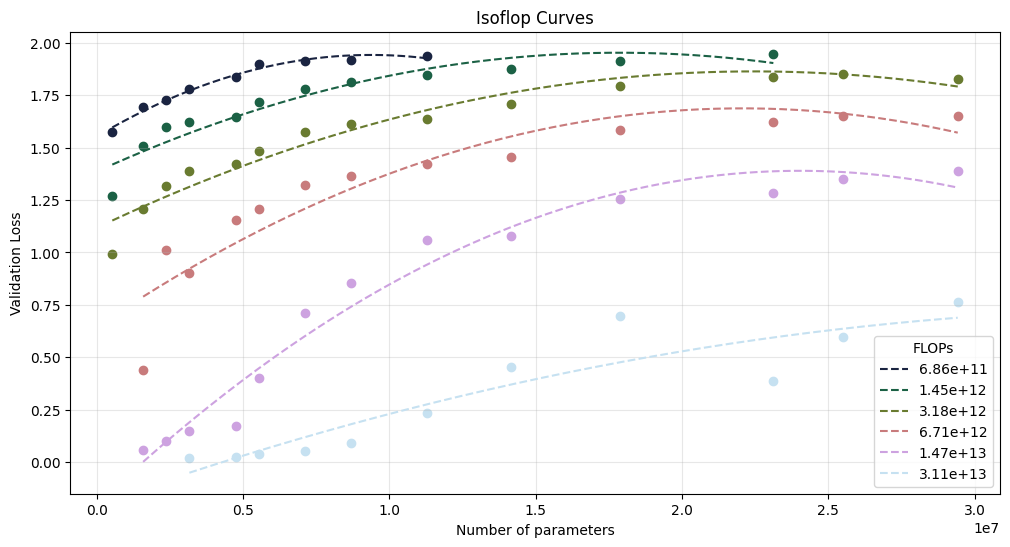

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# =============================
# Load data
# =============================

df = pd.read_csv("dense_results.csv")

cols = ["num_params", "activated_params", "num_tokens", "flops", "val_loss"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = (
    df.dropna(subset=cols)
      .drop_duplicates()
      .sort_values(["num_params", "num_tokens"])
      .reset_index(drop=True)
)

loss_col = "val_loss"

# Your dense FLOP formula should be approximately:
# FLOPs = 6 * activated_params * num_tokens
flop_coeff = (df["flops"] / (df["activated_params"] * df["num_tokens"])).median()


# =============================
# Helpers
# =============================

def interp_loss_for_model(group, target_flops):
    """
    Given all runs for one model size, interpolate loss at a fixed FLOP budget.
    """
    group = group.sort_values("flops")

    x = np.log10(group["flops"].to_numpy(dtype=float))
    y = group[loss_col].to_numpy(dtype=float)

    target_x = np.log10(target_flops)

    if target_x < x.min() or target_x > x.max():
        return np.nan

    return np.interp(target_x, x, y)


def fmt_params(x, _):
    if x >= 1e9:
        return f"{x / 1e9:g}B"
    if x >= 1e6:
        return f"{x / 1e6:g}M"
    if x >= 1e3:
        return f"{x / 1e3:g}K"
    return f"{x:g}"


def fmt_flops(x):
    exponent = int(np.floor(np.log10(x)))
    mantissa = x / (10 ** exponent)
    mantissa = int(round(mantissa))
    return f"{mantissa}e{exponent}"


# =============================
# Build isoFLOP slices
# =============================

# Choose FLOP budgets where at least several model sizes are valid.
min_flops = df.groupby("num_params")["flops"].min()
max_flops = df.groupby("num_params")["flops"].max()

global_min = df["flops"].min()
global_max = df["flops"].max()

candidate_flops = np.geomspace(global_min, global_max, 200)

valid_counts = []
for C in candidate_flops:
    count = ((min_flops <= C) & (max_flops >= C)).sum()
    valid_counts.append(count)

valid_counts = np.array(valid_counts)

# Keep budgets that have enough points to draw useful curves.
min_points_per_curve = 5
usable_flops = candidate_flops[valid_counts >= min_points_per_curve]

# Pick about 9 isoFLOP curves, like the reference plot.
n_curves = 9
iso_flops = np.geomspace(usable_flops.min(), usable_flops.max(), n_curves)

rows = []

for C in iso_flops:
    for num_params, group in df.groupby("num_params"):
        loss = interp_loss_for_model(group, C)

        if np.isnan(loss):
            continue

        activated_params = group["activated_params"].iloc[0]
        target_tokens = C / (flop_coeff * activated_params)

        rows.append({
            "iso_flops": C,
            "num_params": num_params,
            "activated_params": activated_params,
            "num_tokens": target_tokens,
            "loss": loss,
        })

iso = pd.DataFrame(rows)


# =============================
# Plot one isoFLOP graph
# =============================

plt.figure(figsize=(7.2, 5.6))

colors = plt.cm.viridis_r(np.linspace(0.12, 0.82, len(iso_flops)))

for color, C in zip(colors, iso_flops):
    s = iso[np.isclose(iso["iso_flops"], C)].sort_values("num_params")

    if len(s) < min_points_per_curve:
        continue

    x = s["num_params"].to_numpy(dtype=float)
    y = s["loss"].to_numpy(dtype=float)

    # Points from interpolation.
    plt.scatter(
        x,
        y,
        s=58,
        color=color,
        zorder=3,
        label=fmt_flops(C),
    )

    # Solid line through empirical interpolated points.
    plt.plot(
        x,
        y,
        color=color,
        linewidth=2,
        alpha=0.9,
        zorder=2,
    )

    # Dashed smooth quadratic fit in log-parameter space.
    # This gives the Chinchilla-style U-shaped isoFLOP curve.
    if len(s) >= 4:
        log_x = np.log10(x)
        coeffs = np.polyfit(log_x, y, deg=2)

        x_smooth = np.geomspace(x.min(), x.max(), 200)
        y_smooth = np.polyval(coeffs, np.log10(x_smooth))

        plt.plot(
            x_smooth,
            y_smooth,
            linestyle="--",
            linewidth=1,
            color=color,
            alpha=0.65,
            zorder=1,
        )


plt.xscale("log")

plt.xlabel("Parameters", fontsize=13)
plt.ylabel("Validation Loss", fontsize=13)
plt.title("IsoFLOP Curves", fontsize=14)

plt.gca().xaxis.set_major_formatter(FuncFormatter(fmt_params))

plt.grid(True, which="both", alpha=0.35)
plt.legend(title="FLOPs", fontsize=10, title_fontsize=10)

plt.tight_layout()
plt.savefig("isoflop_curves.png", dpi=250)
plt.show()


Fitting the parametric model

In [ ]:
import jax
from jax import numpy as jnp
from jax.scipy.optimize import minimize
from functools import partial
import pandas as pd
import numpy as np

import scaling_transformer.analysis as scaling_analysis
from scaling_transformer.analysis import huber_loss, optimize, predict

# df = pd.read_csv('dense_results.csv')
dff = pd.read_csv('moe_results.csv')
df = pd.read_csv('moe_metadata.csv')
df['val_loss'] = dff['val_loss']
N = jnp.array(pd.to_numeric(df['activated_params']).to_numpy(dtype=np.float32))
D = jnp.array(pd.to_numeric(df['num_tokens']).to_numpy(dtype=np.float32))
y = jnp.array(pd.to_numeric(df['val_loss']).to_numpy(dtype=np.float32))

delta = 1e-2
scaling_analysis.delta = delta

a_grid = jnp.array([0., 5., 10., 15., 20., 25.])
b_grid = jnp.array([0., 5., 10., 15., 20., 25.])
e_grid = jnp.array([-1., -0.5, 0.0, 0.5, 1.0])
alpha_grid = jnp.array([0.0, 0.5, 1.0, 1.5, 2.])
beta_grid = jnp.array([0.0, 0.5, 1.0, 1.5, 2.])

vectorized_optimize = jax.vmap(
    jax.vmap(
        jax.vmap(
            jax.vmap(
                jax.vmap(optimize,
                         in_axes=(None, None, None, None, 0, None, None, None)),
                in_axes=(None, None, None, 0, None, None, None, None)),
            in_axes=(None, None, 0, None, None, None, None, None)),
        in_axes=(None, 0, None, None, None, None, None, None)),
    in_axes=(0, None, None, None, None, None, None, None))
inits, best_params, max_errs = jax.jit(vectorized_optimize)(a_grid, b_grid, e_grid, alpha_grid, beta_grid, N, D, y)


In [ ]:
from scaling_transformer.analysis import D_opt, N_opt

argmin = jnp.nanargmin(max_errs)
index = jnp.unravel_index(argmin, max_errs.shape)
test_i, test_p, test_err = inits[index], best_params[index], max_errs[index]
# _, bad_p, _ = optimize(test_i[0], test_i[1], test_i[2], test_i[3], test_i[4], N, D, y)

y_hat_1 = predict(test_p, N, D,)
A, B, E, alpha, beta = test_p[0], test_p[1], test_p[2], test_p[3], test_p[4]
G = ((alpha * A) / (beta * B)) ** (1 / (alpha + beta))
a = beta / (alpha + beta)
b = alpha / (alpha + beta)
Cs = jnp.array(pd.to_numeric(df['flops']).to_numpy(dtype=np.float32))

efficient_frontier_N = jnp.array([N_opt(C, G, a, b) for C in Cs])
efficient_frontier_D = jnp.array([D_opt(C, G, a, b) for C in Cs])

efficient_frontier_N = jnp.log(efficient_frontier_N)
efficient_fronter_C = jnp.log(Cs)
y_hat = predict(test_p, efficient_frontier_N, efficient_frontier_D)


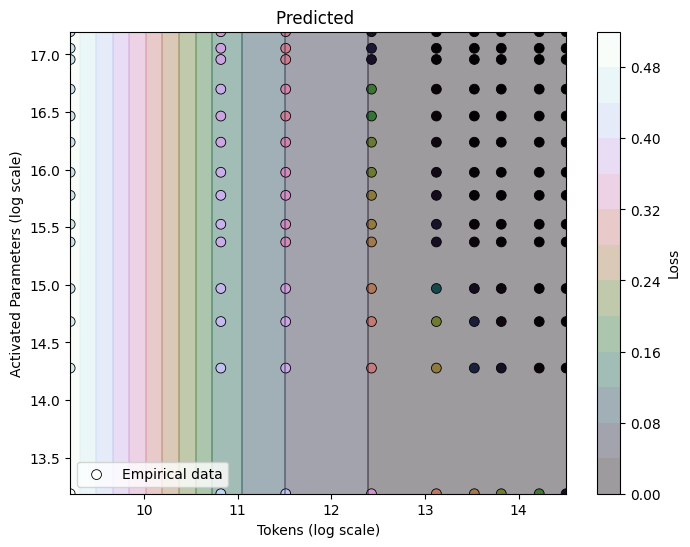

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_palette(palette='cubehelix')
plt.figure(figsize=(8, 6))

contour = plt.tricontourf(jnp.log(D), jnp.log(N), y_hat_1, levels=15, cmap='cubehelix', alpha=0.4)
contour_lines = plt.tricontour(jnp.log(D), jnp.log(N), y_hat_1, levels=15, cmap='cubehelix', linewidths=1.2, alpha=0.5)

plt.scatter(jnp.log(D), jnp.log(N), c=y, cmap='cubehelix', edgecolor='black', linewidths=0.6, s=50, label="Empirical data")

plt.colorbar(contour, label="Loss")
plt.xlabel("Tokens (log scale)")
plt.ylabel("Activated Parameters (log scale)")
plt.title("Predicted ")
plt.legend()
plt.show()


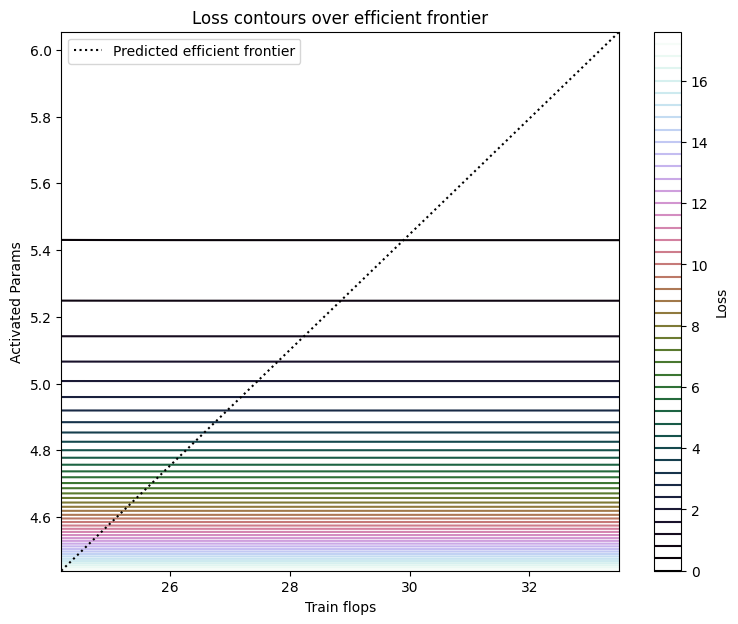

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_palette(palette='cubehelix')
plt.figure(figsize=(9, 7), dpi=100)
cmap_theme = 'rocket_r'

y_start, x_start = efficient_frontier_N[0], efficient_fronter_C[0]
y_end, x_end = efficient_frontier_N[-1], efficient_fronter_C[-1]

n_space = np.exp(np.linspace(y_start, y_end))
c_space = np.exp(np.linspace(x_start, x_end))

C_grid, N_grid = np.meshgrid(c_space, n_space)
D_grid = C_grid / (6 * N_grid)
log_N_grid = jnp.log(N_grid)
log_D_grid = jnp.log(D_grid)
log_C_grid = jnp.log(C_grid)

# 4. Compute your dense 2D surface of predictions using your optimized parameters
# Output shape will be a smooth grid matching the dimensions of your spaces
y_grid_preds = predict(test_p, N_grid, D_grid)


# 2. Draw the contour curves using the datapoints and their values
# This will draw lines connecting equal values across the data space
contours = plt.contour(log_C_grid, log_N_grid, y_grid_preds,
                          levels=50, cmap="cubehelix", linewidths=1.5,)

plt.axline((x_start, y_start), (x_end, y_end), linestyle=":", color="black", label="Predicted efficient frontier")
# ax = plt.scatter(jnp.log(N), jnp.log(Cs), c=y, cmap='cubehelix', edgecolor='black', linewidths=0.6, s=50, label="Empirical data")

plt.colorbar(contours, label="Loss")
plt.xlabel("Train flops")
plt.ylabel("Activated Params")
plt.title("Loss contours over efficient frontier")
plt.legend()
plt.savefig('chincilla_moe_activated_plot2.png')
plt.show()


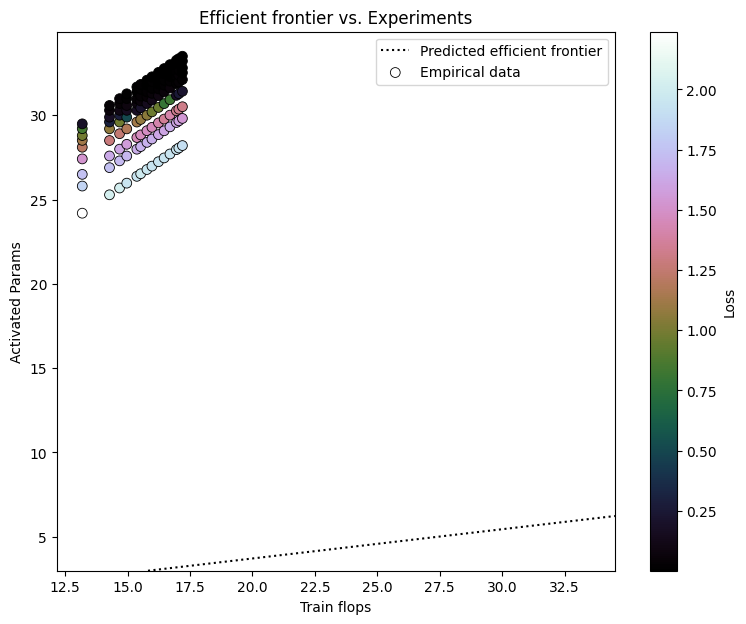

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_palette(palette='cubehelix')
plt.figure(figsize=(9, 7), dpi=100)
cmap_theme = 'rocket_r'

y_start, x_start = efficient_frontier_N[0], efficient_fronter_C[0]
y_end, x_end = efficient_frontier_N[-1], efficient_fronter_C[-1]

n_space = np.exp(np.linspace(y_start, y_end))
c_space = np.exp(np.linspace(x_start, x_end))

C_grid, N_grid = np.meshgrid(c_space, n_space)
D_grid = C_grid / (6 * N_grid)
log_N_grid = jnp.log(N_grid)
log_D_grid = jnp.log(D_grid)
log_C_grid = jnp.log(C_grid)

# 4. Compute your dense 2D surface of predictions using your optimized parameters
# Output shape will be a smooth grid matching the dimensions of your spaces
y_grid_preds = predict(test_p, log_N_grid, log_D_grid)


# # 2. Draw the contour curves using the datapoints and their values
# # This will draw lines connecting equal values across the data space
# contours = plt.contour(log_C_grid, log_N_grid, y_grid_preds,
#                           levels=10, cmap="cubehelix", linewidths=1.5)

plt.axline((x_start, y_start), (x_end, y_end), linestyle=":", color="black", label="Predicted efficient frontier")
ax = plt.scatter(jnp.log(N), jnp.log(Cs), c=y, cmap='cubehelix', edgecolor='black', linewidths=0.6, s=50, label="Empirical data")

plt.colorbar(ax, label="Loss")
plt.xlabel("Train flops")
plt.ylabel("Activated Params")
plt.title("Efficient frontier vs. Experiments")
plt.legend()
plt.savefig('chincilla_moe_activated_plot3.png')
plt.show()
